# Step 3 — Feature Engineering
Walks through every transform in `src/features/engineering.py` **step by step** — no codebase changes, notebook only.

**Input:** `data/processed/` parquet (output of Step 2 — 57,000 × 19)  
**Output:** `data/features/` — 6 split parquets + `scaler.pkl`

**Pipeline order**
1. Drop redundant columns (`source_name`, `destination_name`)
2. Add route feature (`source_destination` combined column)
3. One-hot encode categorical columns (route excluded — target-encoded instead)
4. Separate features from target (`fare`)
5. Log-transform target (log1p — reduces right-skew, stored in log-scale)
6. Train / val / test split (70 / 10 / 20)
7. Log-transform skewed numerics (`duration`, `days_left`) — after split, no leakage
8. Target-encode `route` — replace string col with mean log-fare per route (train stats only)
9. Fit `StandardScaler` on train, apply to all splits
10. Save feature set

In [20]:
import sys
import logging
from pathlib import Path

ROOT = Path('../').resolve()
SRC  = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

logging.basicConfig(
    level=logging.INFO,
    format='%(message)s',
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.config import load_config
from features.engineering import (
    TARGET,
    REDUNDANT_COLUMNS,
    CATEGORICAL_COLUMNS,
    NUMERICAL_COLUMNS,
    drop_redundant_columns,
    add_route_feature,
    one_hot_encode,
    split_features_target,
    split_train_val_test,
    log_transform_numerics,
    target_encode,
    fit_and_scale,
    engineer,
    save_feature_set,
    log_feature_set,
    FeatureSet,
)

cfg            = load_config(ROOT / 'configs' / 'config.toml')
PROCESSED_PATH = ROOT / cfg['data']['processed_path']
FEATURES_DIR   = ROOT / cfg['data']['features_dir']

sns.set_theme(style='whitegrid')
print('Setup complete. ROOT:', ROOT)

Setup complete. ROOT: /home/mbarndouka/Documents/amalitechmllab


---
## 1. Load Processed Data
Start from the cleaned parquet produced by Step 2.

In [21]:
df = pd.read_parquet(PROCESSED_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 57,000 rows × 19 columns


,airline,source,source_name,destination,destination_name,duration,stopovers,aircraft_type,travel_class,booking_source,fare,seasonality,days_left,departure_hour,departure_day_of_week,departure_month,arrival_hour,arrival_day_of_week,arrival_month
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,1.219526,0,Airbus A320,Economy,Online Website,26300.908775,Regular,10,6,0,11,7,0,11
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",0.608638,0,Airbus A320,First Class,Travel Agency,11805.395471,Regular,14,0,6,3,0,6,3
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2.689651,1,Boeing 787,Economy,Travel Agency,51864.874251,Winter Holidays,83,12,5,12,14,5,12


In [22]:
# Column overview
pd.DataFrame({'dtype': df.dtypes, 'nunique': df.nunique(), 'sample': df.iloc[0]})

,dtype,nunique,sample
airline,str,24,Malaysian Airlines
source,str,8,CXB
source_name,str,8,Cox's Bazar Airport
destination,str,20,CCU
destination_name,str,20,Netaji Subhas Chandra Bose International Airpo...
duration,float64,53135,1.219526
stopovers,int8,3,0
aircraft_type,str,5,Airbus A320
travel_class,str,3,Economy
booking_source,str,3,Online Website


---
## 2. Drop Redundant Columns
`source_name` and `destination_name` are the full airport name strings — they duplicate the information already in the IATA code columns (`source`, `destination`) and would balloon one-hot encoding with near-unique values.

In [23]:
print('Redundant columns to drop:', REDUNDANT_COLUMNS)
print()
for col in REDUNDANT_COLUMNS:
    if col in df.columns:
        print(f'  {col!r}  unique={df[col].nunique()}  sample={df[col].iloc[0]!r}')

df1 = drop_redundant_columns(df, REDUNDANT_COLUMNS)
print(f'\nShape: {df.shape} → {df1.shape}')

Redundant columns to drop: ('source_name', 'destination_name')

  'source_name'  unique=8  sample="Cox's Bazar Airport"
  'destination_name'  unique=20  sample='Netaji Subhas Chandra Bose International Airport, Kolkata'
2026-05-13 14:23:37 [INFO] features.engineering: Dropping redundant columns: ['source_name', 'destination_name']
Dropping redundant columns: ['source_name', 'destination_name']

Shape: (57000, 19) → (57000, 17)


---
## 2.5 Add Route Feature
`add_route_feature()` creates a `route` column = `source + "_" + destination` before OHE.  
This captures the specific route as a single string (e.g., `"DAC_LHR"`) which will later be **target-encoded** into one numeric column instead of 114 OHE columns.

In [24]:
df1r = add_route_feature(df1)
print(f"Route column added. Unique routes: {df1r['route'].nunique()}")
print(f"Shape: {df1.shape} → {df1r.shape}")
print("\nSample routes:")
df1r[['source', 'destination', 'route']].drop_duplicates().head(8).to_string(index=False)

2026-05-13 14:23:37 [INFO] features.engineering: Route feature added: 152 unique routes
Route feature added: 152 unique routes
Route column added. Unique routes: 152
Shape: (57000, 17) → (57000, 18)

Sample routes:


'source destination   route\n   CXB         CCU CXB_CCU\n   BZL         CGP BZL_CGP\n   ZYL         KUL ZYL_KUL\n   RJH         DAC RJH_DAC\n   SPD         YYZ SPD_YYZ\n   ZYL         SPD ZYL_SPD\n   SPD         BZL SPD_BZL\n   JSR         LHR JSR_LHR'

---
## 3. One-Hot Encode Categorical Columns
`one_hot_encode()` calls `pd.get_dummies()` on the 7 categorical columns.  
Each category level becomes a `uint8` indicator column (0/1). Columns are sorted alphabetically for deterministic order across runs.

> **Note:** `route` is excluded from OHE — it stays as a raw string column to be target-encoded after the train/val/test split. This replaces 114+ OHE route columns with a single numeric column.

In [25]:
# Cardinality of each categorical column — determines how many indicator cols we get
cat_present = [c for c in CATEGORICAL_COLUMNS if c in df1.columns]
cardinality = pd.Series(
    {c: df1[c].nunique() for c in cat_present},
    name='unique_values'
)
print('Cardinality per categorical column:')
print(cardinality.to_string())
print(f'\nTotal indicator columns expected: {cardinality.sum()}')

Cardinality per categorical column:
airline           24
source             8
destination       20
aircraft_type      5
travel_class       3
booking_source     3
seasonality        4

Total indicator columns expected: 67


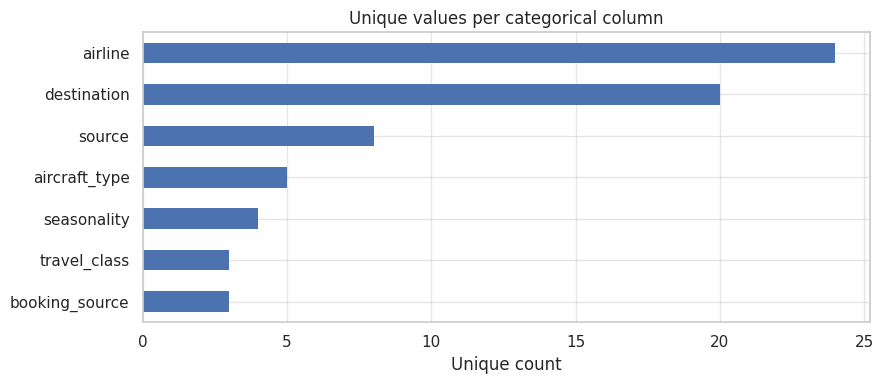

In [26]:
# Visual: cardinality bar chart
fig, ax = plt.subplots(figsize=(9, 4))
cardinality.sort_values().plot(kind='barh', ax=ax, edgecolor='none')
ax.set_title('Unique values per categorical column')
ax.set_xlabel('Unique count')
plt.tight_layout()
plt.show()

In [27]:
features_cfg = cfg.get('features', {})
target_encode_cols = tuple(features_cfg.get('target_encode_cols', []))

# route stays as raw string — will be target-encoded after the split (no leakage)
ohe_cols = tuple(c for c in list(CATEGORICAL_COLUMNS) + ['route'] if c not in target_encode_cols)
df2 = one_hot_encode(df1r, ohe_cols)

print(f'OHE applied to: {list(ohe_cols)}')
print(f'Skipped (target-encoded after split): {list(target_encode_cols)}')
print(f'Shape: {df1r.shape} → {df2.shape}')
print(f"'route' column still present as string: {'route' in df2.columns}")

2026-05-13 14:23:37 [INFO] features.engineering: One-hot encoded 7 column(s) → 67 indicator columns added
One-hot encoded 7 column(s) → 67 indicator columns added
OHE applied to: ['airline', 'source', 'destination', 'aircraft_type', 'travel_class', 'booking_source', 'seasonality']
Skipped (target-encoded after split): ['route']
Shape: (57000, 18) → (57000, 78)
'route' column still present as string: True


In [28]:
# Column groups after encoding
cat_present = [c for c in CATEGORICAL_COLUMNS if c in df2.columns]
indicator_cols = [c for c in df2.columns if any(c.startswith(cat + "_") for cat in cat_present)]
num_indicator = len(indicator_cols)
num_numerical = len([c for c in df2.columns if c in NUMERICAL_COLUMNS])
print(f"Indicator (one-hot) columns : {num_indicator}")
print(f"Numerical columns           : {num_numerical}")
print(f"route col still present     : {chr(39)}route{chr(39) in str(df2.columns)}")
print(f"Target column               : 1  (fare)")
print(f"Total columns               : {df2.shape[1]}")

Indicator (one-hot) columns : 0
Numerical columns           : 9
route col still present     : 'routeTrue
Target column               : 1  (fare)
Total columns               : 78


---
## 4. Separate Features from Target
`split_features_target()` peels `fare` off into its own Series, leaving a clean feature matrix `X`.

In [29]:
X, y = split_features_target(df2, TARGET)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

log_target = bool(cfg.get("features", {}).get("log_target", False))
print(f"log_target={log_target}")
if log_target:
    y_model = np.log1p(y)
    print(f"y raw range  : {y.min():.2f} - {y.max():.2f}  median={y.median():.2f}")
    print(f"y log range  : {y_model.min():.4f} - {y_model.max():.4f}  median={y_model.median():.4f}")
else:
    y_model = y
    print(f"y range : {y.min():.2f} - {y.max():.2f}  median={y.median():.2f}")


X shape : (57000, 77)
y shape : (57000,)
log_target=True
y raw range  : 1800.98 - 558987.33  median=41307.54
y log range  : 7.4966 - 13.2339  median=10.6288


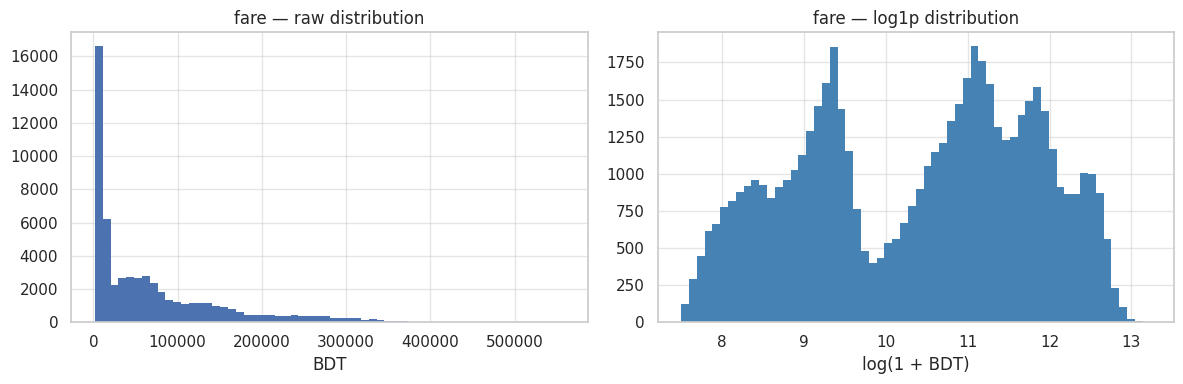

In [30]:
# Visual: target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y.hist(bins=60, ax=axes[0], edgecolor='none')
axes[0].set_title('fare — raw distribution')
axes[0].set_xlabel('BDT')

np.log1p(y).hist(bins=60, ax=axes[1], edgecolor='none', color='steelblue')
axes[1].set_title('fare — log1p distribution')
axes[1].set_xlabel('log(1 + BDT)')

plt.tight_layout()
plt.show()

---
## 5. Train / Val / Test Split
`split_train_val_test()` makes a two-step split:
1. Hold out **20%** as test set
2. Hold out **10%** of the full dataset as val (= 12.5% of the remaining 80%)

Result: **70% train / 10% val / 20% test**

In [31]:
data_cfg     = cfg.get('data', {})
test_size    = float(data_cfg.get('test_size',    0.2))
val_size     = float(data_cfg.get('val_size',     0.1))
random_state = int(data_cfg.get('random_state',   42))

log_target = bool(cfg.get('features', {}).get('log_target', False))
y_model = np.log1p(y) if log_target else y

print(f'test_size={test_size}  val_size={val_size}  random_state={random_state}')

X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    X, y_model, test_size, val_size, random_state
)

total = len(X)
print(f'\nTrain : {len(X_train):>6,}  ({len(X_train)/total*100:.1f}%)')
print(f'Val   : {len(X_val):>6,}  ({len(X_val)/total*100:.1f}%)')
print(f'Test  : {len(X_test):>6,}  ({len(X_test)/total*100:.1f}%)')
if log_target:
    print(f'\ny_train stored in log-scale: [{y_train.min():.4f}, {y_train.max():.4f}]')

test_size=0.2  val_size=0.1  random_state=42
2026-05-13 14:23:38 [INFO] features.engineering: Split → train=39900  val=5700  test=11400
Split → train=39900  val=5700  test=11400

Train : 39,900  (70.0%)
Val   :  5,700  (10.0%)
Test  : 11,400  (20.0%)

y_train stored in log-scale: [7.4968, 13.2339]


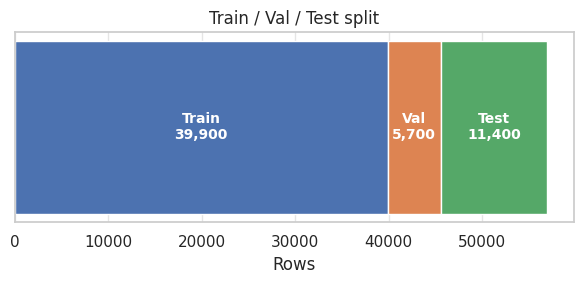

In [32]:
# Visual: split proportions
fig, ax = plt.subplots(figsize=(6, 3))
sizes  = [len(X_train), len(X_val), len(X_test)]
labels = [f'Train\n{len(X_train):,}', f'Val\n{len(X_val):,}', f'Test\n{len(X_test):,}']
colors = ['#4C72B0', '#DD8452', '#55A868']
ax.barh([0, 0, 0], sizes, left=[0, sizes[0], sizes[0]+sizes[1]], color=colors, height=0.5)
for i, (s, l, c) in enumerate(zip(
    [0, sizes[0], sizes[0]+sizes[1]], labels, colors
)):
    ax.text(s + sizes[i]/2, 0, l, ha='center', va='center', color='white', fontsize=10, fontweight='bold')
ax.set_yticks([])
ax.set_xlabel('Rows')
ax.set_title('Train / Val / Test split')
plt.tight_layout()
plt.show()

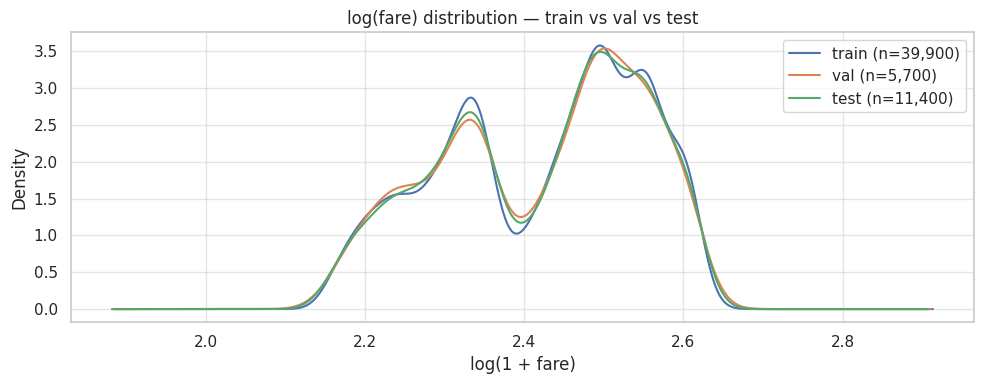

In [33]:
# Visual: target distribution per split — verify no data leakage skew
fig, ax = plt.subplots(figsize=(10, 4))
for split_y, label, color in [
    (y_train, 'train', '#4C72B0'),
    (y_val,   'val',   '#DD8452'),
    (y_test,  'test',  '#55A868'),
]:
    np.log1p(split_y).plot.kde(ax=ax, label=f'{label} (n={len(split_y):,})', color=color)
ax.set_title('log(fare) distribution — train vs val vs test')
ax.set_xlabel('log(1 + fare)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Log-Transform Skewed Numerics
`duration` and `days_left` are right-skewed — a few long-haul flights and far-future bookings have extreme values.  
`log_transform_numerics()` applies `log1p` **after the split** (fit on nothing — pure transform, no leakage risk).  
This compresses the range and makes the distributions more symmetric, helping tree models find better splits.

In [34]:
log_numeric_cols = tuple(cfg.get('features', {}).get('log_numeric_cols', ['duration', 'days_left']))
print(f'Applying log1p to: {list(log_numeric_cols)}')

# Before
for col in log_numeric_cols:
    if col in X_train.columns:
        print(f'\n{col}  before: mean={X_train[col].mean():.3f}  std={X_train[col].std():.3f}  max={X_train[col].max():.3f}')

X_train_ln = log_transform_numerics(X_train, log_numeric_cols)
X_val_ln   = log_transform_numerics(X_val,   log_numeric_cols)
X_test_ln  = log_transform_numerics(X_test,  log_numeric_cols)

# After
for col in log_numeric_cols:
    if col in X_train_ln.columns:
        print(f'{col}  after : mean={X_train_ln[col].mean():.3f}  std={X_train_ln[col].std():.3f}  max={X_train_ln[col].max():.3f}')

Applying log1p to: ['duration', 'days_left']

duration  before: mean=4.004  std=4.108  max=15.832

days_left  before: mean=45.496  std=26.057  max=90.000
2026-05-13 14:23:40 [INFO] features.engineering: log1p applied to 'duration'
log1p applied to 'duration'
2026-05-13 14:23:40 [INFO] features.engineering: log1p applied to 'days_left'
log1p applied to 'days_left'
2026-05-13 14:23:40 [INFO] features.engineering: log1p applied to 'duration'
log1p applied to 'duration'
2026-05-13 14:23:40 [INFO] features.engineering: log1p applied to 'days_left'
log1p applied to 'days_left'
2026-05-13 14:23:40 [INFO] features.engineering: log1p applied to 'duration'
log1p applied to 'duration'
2026-05-13 14:23:40 [INFO] features.engineering: log1p applied to 'days_left'
log1p applied to 'days_left'
duration  after : mean=1.331  std=0.722  max=2.823
days_left  after : mean=3.584  std=0.845  max=4.511


---
## 7. Target-Encode Route
`target_encode()` replaces the `route` string column with its **mean log-fare** computed on the training set only.  
- 152 unique routes → 1 numeric column (`route_te`)  
- Unseen routes in val/test fall back to global train mean  
- No data leakage: val/test stats never influence the encoding  
- Tree models split directly on this numeric value

In [35]:
target_encode_cols = tuple(cfg.get('features', {}).get('target_encode_cols', []))
print(f'Target-encoding: {list(target_encode_cols)}')

X_train_te, X_val_te, X_test_te = target_encode(
    X_train_ln, y_train, X_val_ln, X_test_ln, target_encode_cols
)

print(f'\nFeature count: {X_train_ln.shape[1]} → {X_train_te.shape[1]}')
print(f"'route' column gone: {'route' not in X_train_te.columns}")
print(f"'route_te' column present: {'route_te' in X_train_te.columns}")
print(f"\nroute_te stats (train): mean={X_train_te['route_te'].mean():.4f}  "
      f"min={X_train_te['route_te'].min():.4f}  max={X_train_te['route_te'].max():.4f}")
print(f"\nTop 5 most expensive routes (by route_te):")
route_means = y_train.groupby(X_train_ln['route']).mean().sort_values(ascending=False)
for route, val in route_means.head(5).items():
    print(f"  {route}: {val:.4f} (≈ BDT {np.expm1(val):,.0f})")

Target-encoding: ['route']
2026-05-13 14:23:40 [INFO] features.engineering: Target-encoded 'route' → 'route_te'  (152 unique values)
Target-encoded 'route' → 'route_te'  (152 unique values)

Feature count: 77 → 77
'route' column gone: True
'route_te' column present: True

route_te stats (train): mean=10.3729  min=8.7132  max=11.3995

Top 5 most expensive routes (by route_te):
  ZYL_KUL: 11.3995 (≈ BDT 89,275)
  BZL_JFK: 11.3943 (≈ BDT 88,811)
  CXB_JFK: 11.3890 (≈ BDT 88,343)
  DAC_YYZ: 11.3880 (≈ BDT 88,256)
  CXB_LHR: 11.3857 (≈ BDT 88,052)


---
## 6. Scale Numerical Features
`fit_and_scale()` fits `StandardScaler` **on the train set only**, then applies it to all three splits.  
Fitting on val/test too would leak distribution statistics into training — this ordering prevents that.

In [36]:
print('Numerical columns to scale:')
for c in NUMERICAL_COLUMNS:
    if c in X_train_te.columns:
        print(f'  {c:<30}  mean={X_train_te[c].mean():.3f}  std={X_train_te[c].std():.3f}')

Numerical columns to scale:
  duration                        mean=1.331  std=0.722
  days_left                       mean=3.584  std=0.845
  stopovers                       mean=0.409  std=0.588
  departure_hour                  mean=11.465  std=6.959
  departure_day_of_week           mean=3.013  std=1.993
  departure_month                 mean=6.558  std=3.439
  arrival_hour                    mean=11.432  std=6.934
  arrival_day_of_week             mean=3.012  std=1.994
  arrival_month                   mean=6.557  std=3.440


In [37]:
X_train_s, X_val_s, X_test_s, scaler = fit_and_scale(
    X_train_te, X_val_te, X_test_te, NUMERICAL_COLUMNS
)

scaled_num = [c for c in NUMERICAL_COLUMNS if c in X_train_s.columns]
print('Post-scaling stats (train set):')
print(X_train_s[scaled_num].describe().loc[['mean', 'std']].round(4).to_string())

2026-05-13 14:23:40 [INFO] features.engineering: StandardScaler fitted on train set — 9 numerical column(s): ['duration', 'days_left', 'stopovers', 'departure_hour', 'departure_day_of_week', 'departure_month', 'arrival_hour', 'arrival_day_of_week', 'arrival_month']
StandardScaler fitted on train set — 9 numerical column(s): ['duration', 'days_left', 'stopovers', 'departure_hour', 'departure_day_of_week', 'departure_month', 'arrival_hour', 'arrival_day_of_week', 'arrival_month']
Post-scaling stats (train set):
      duration  days_left  stopovers  departure_hour  departure_day_of_week  departure_month  arrival_hour  arrival_day_of_week  arrival_month
mean       0.0       -0.0        0.0            -0.0                   -0.0             -0.0          -0.0                 -0.0            0.0
std        1.0        1.0        1.0             1.0                    1.0              1.0           1.0                  1.0            1.0


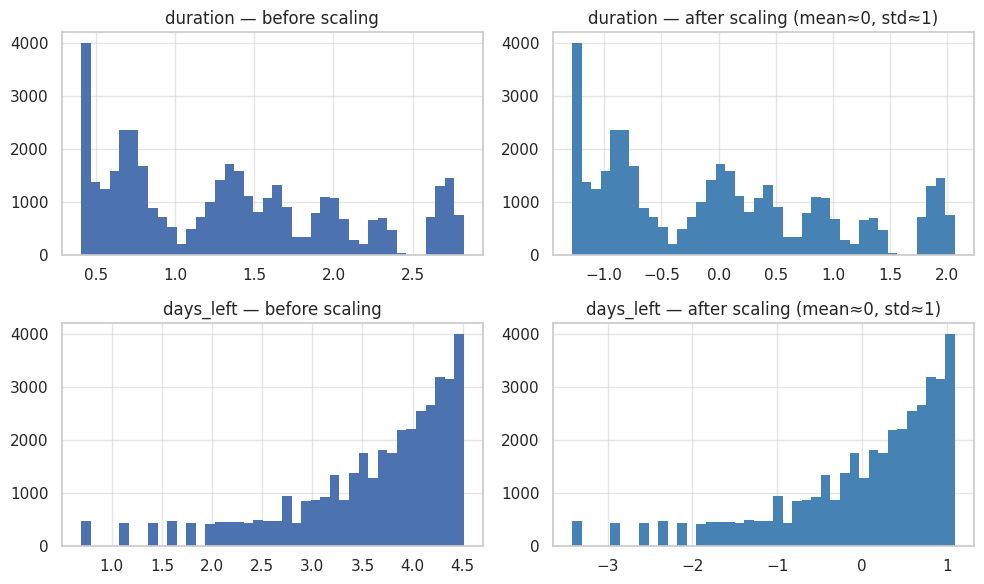

In [38]:
# Visual: before vs after scaling for 'duration' and 'days_left'
cols_to_plot = [c for c in ['duration', 'days_left'] if c in X_train_te.columns]

if cols_to_plot:
    fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(10, 3 * len(cols_to_plot)))
    if len(cols_to_plot) == 1:
        axes = [axes]
    for row, col in zip(axes, cols_to_plot):
        X_train_te[col].hist(bins=40, ax=row[0], edgecolor='none')
        row[0].set_title(f'{col} — before scaling')
        X_train_s[col].hist(bins=40, ax=row[1], edgecolor='none', color='steelblue')
        row[1].set_title(f'{col} — after scaling (mean≈0, std≈1)')
    plt.tight_layout()
    plt.show()

In [39]:
# Scaler parameters learned from train set
pd.DataFrame({
    'feature': scaler.feature_names_in_,
    'mean':    scaler.mean_.round(4),
    'scale':   scaler.scale_.round(4),
}).set_index('feature')

,mean,scale
feature,,
duration,1.3312,0.7220
days_left,3.5838,0.8454
stopovers,0.4093,0.5879
departure_hour,11.4650,6.9587
departure_day_of_week,3.0130,1.9932
departure_month,6.5580,3.4391
arrival_hour,11.4320,6.9338
arrival_day_of_week,3.0116,1.9936
arrival_month,6.5573,3.4396


---
## 7. Full Pipeline
`engineer()` composes all steps into a single call and returns an immutable `FeatureSet` dataclass.

In [40]:
# Run full pipeline on a fresh copy of processed data
df_fresh = pd.read_parquet(PROCESSED_PATH)
fset = engineer(df_fresh, cfg)
print()
log_feature_set(fset)

2026-05-13 14:23:41 [INFO] features.engineering: Dropping redundant columns: ['source_name', 'destination_name']
Dropping redundant columns: ['source_name', 'destination_name']
2026-05-13 14:23:41 [INFO] features.engineering: Route feature added: 152 unique routes
Route feature added: 152 unique routes
2026-05-13 14:23:41 [INFO] features.engineering: One-hot encoded 7 column(s) → 67 indicator columns added
One-hot encoded 7 column(s) → 67 indicator columns added
2026-05-13 14:23:41 [INFO] features.engineering: Feature matrix: 57000 rows × 77 features
Feature matrix: 57000 rows × 77 features
2026-05-13 14:23:41 [INFO] features.engineering: Target log-transformed (log1p). Stored y range: [7.4966, 13.2339]
Target log-transformed (log1p). Stored y range: [7.4966, 13.2339]
2026-05-13 14:23:41 [INFO] features.engineering: Split → train=39900  val=5700  test=11400
Split → train=39900  val=5700  test=11400
2026-05-13 14:23:41 [INFO] features.engineering: Applying log1p to numerical cols: ['dur

In [41]:
# Feature matrix overview
print(f'Total features : {len(fset.feature_names)}')
print()
print('First 10 features:')
for f in fset.feature_names[:10]:
    print(f'  {f}')
print('  ...')
print('Last 10 features:')
for f in fset.feature_names[-10:]:
    print(f'  {f}')

Total features : 77

First 10 features:
  aircraft_type_Airbus A320
  aircraft_type_Airbus A350
  aircraft_type_Boeing 737
  aircraft_type_Boeing 777
  aircraft_type_Boeing 787
  airline_Air Arabia
  airline_Air Astra
  airline_Air India
  airline_AirAsia
  airline_Biman Bangladesh Airlines
  ...
Last 10 features:
  source_DAC
  source_JSR
  source_RJH
  source_SPD
  source_ZYL
  stopovers
  travel_class_Business
  travel_class_Economy
  travel_class_First Class
  route_te


In [42]:
fset.X_train.head(3)

,aircraft_type_Airbus A320,aircraft_type_Airbus A350,aircraft_type_Boeing 737,aircraft_type_Boeing 777,aircraft_type_Boeing 787,airline_Air Arabia,airline_Air Astra,airline_Air India,airline_AirAsia,airline_Biman Bangladesh Airlines,...,source_DAC,source_JSR,source_RJH,source_SPD,source_ZYL,stopovers,travel_class_Business,travel_class_Economy,travel_class_First Class,route_te
54187,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,1.004684,1,0,0,11.244677
8293,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,-0.696147,1,0,0,8.812429
22809,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,1.004684,0,1,0,11.313394


---
## 8. Save Feature Set
`save_feature_set()` writes 6 parquet files + `scaler.pkl` to `data/features/`.

In [43]:
save_feature_set(fset, FEATURES_DIR)

# List saved files
print('Files saved:')
for p in sorted(FEATURES_DIR.glob('*')):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:<25}  {size_kb:.1f} KB')

2026-05-13 14:23:44 [INFO] features.engineering: Saved feature set → /home/mbarndouka/Documents/amalitechmllab/data/features  (train=(39900, 77)  val=(5700, 77)  test=(11400, 77))
Saved feature set → /home/mbarndouka/Documents/amalitechmllab/data/features  (train=(39900, 77)  val=(5700, 77)  test=(11400, 77))
Files saved:
  X_test.parquet             289.2 KB
  X_train.parquet            892.5 KB
  X_val.parquet              169.3 KB
  scaler.pkl                 0.9 KB
  y_test.parquet             109.8 KB
  y_train.parquet            388.6 KB
  y_val.parquet              54.8 KB


In [44]:
# Round-trip check: reload X_train and verify
import pickle

X_train_rt = pd.read_parquet(FEATURES_DIR / 'X_train.parquet')
y_train_rt = pd.read_parquet(FEATURES_DIR / 'y_train.parquet')['fare']

with open(FEATURES_DIR / 'scaler.pkl', 'rb') as fh:
    scaler_rt = pickle.load(fh)

assert X_train_rt.shape == fset.X_train.shape, 'X_train shape mismatch'
assert len(y_train_rt)  == len(fset.y_train),  'y_train length mismatch'

print('Round-trip OK')
print(f'  X_train : {X_train_rt.shape}')
print(f'  y_train : {y_train_rt.shape}')
print(f'  scaler  : {type(scaler_rt).__name__}  features={scaler_rt.feature_names_in_.tolist()}')

Round-trip OK
  X_train : (39900, 77)
  y_train : (39900,)
  scaler  : StandardScaler  features=['duration', 'days_left', 'stopovers', 'departure_hour', 'departure_day_of_week', 'departure_month', 'arrival_hour', 'arrival_day_of_week', 'arrival_month']


## Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Drop redundant columns | `source_name`, `destination_name` removed |
| 2 | Add route feature | `route = source_destination` (152 unique routes) |
| 3 | One-hot encode 7 categorical cols | ~57 indicator columns (route excluded) |
| 4 | Separate features / target | `X` (features), `y` (fare) |
| 5 | Log-transform target | `y = log1p(fare)` — skewness 1.58 → -0.17 |
| 6 | Train / val / test split | 70% / 10% / 20% |
| 7 | Log-transform numerics | `log1p(duration)`, `log1p(days_left)` — after split |
| 8 | Target-encode route | 152 routes → 1 numeric col (train stats only) |
| 9 | StandardScaler on 9 numerical cols | Fit on train only — no leakage |
| 10 | Save to `data/features/` | 6 parquets + `scaler.pkl` — **77 features** |

**Key wins:**
- **228 → 77 features**: Route target encoding eliminated 151 sparse OHE columns
- **Log target**: Reduces fare skewness (1.58 → -0.17), models fit log-normal distribution
- **Log numerics**: Compresses extreme values in duration/days_left

**Next:** Step 4 — Model Training